In [22]:
import torch, sys
print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA disponível?", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Torch: 2.8.0+cu129
CUDA disponível? True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


In [23]:
import os, json, random, time, numpy as np, cv2
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# usa as funções do Ivo p/ V2 e V3
from functions import load_and_resize_images   # retorna (denoised, mask, labels)

DATA_DIR = Path("dataset")
CLASSES = ["buracos", "rachaduras", "boas"]    # mantenha exatamente esses nomes
SAVE_DIR = Path("runs/ponto3"); SAVE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
set_seed()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE


'cuda'

In [24]:
from pathlib import Path
import os, cv2, numpy as np

DATA_DIR = Path("dataset")
CLASSES = ["buracos", "rachaduras", "boas"]

counts = {}
bad_files = []
for cls in CLASSES:
    p = DATA_DIR/cls
    ok = 0
    for f in os.listdir(p):
        if f.lower().endswith((".jpg",".jpeg",".png")):
            img = cv2.imread(str(p/f))
            if img is None: bad_files.append(str(p/f))
            else: ok += 1
    counts[cls] = ok

print("Contagem por classe:", counts)
if bad_files:
    print("Arquivos corrompidos/ilegíveis:", bad_files)


Contagem por classe: {'buracos': 300, 'rachaduras': 165, 'boas': 46}


Total de imagens: 511
Total de labels: 511


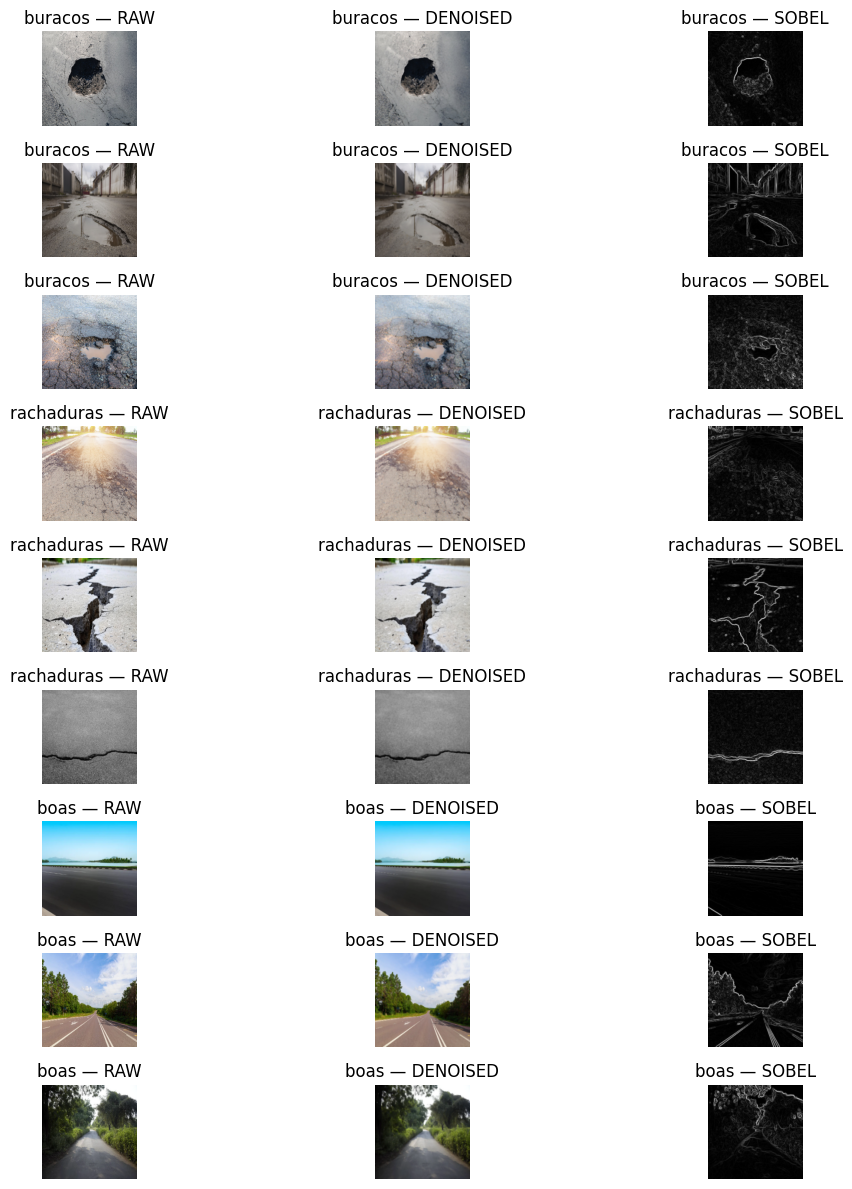

In [25]:
import random
import matplotlib.pyplot as plt
from functions import load_and_resize_images  # retorna (denoised, mask, labels)

# Carrega variantes processadas (preprocess= resize 224 + medianBlur + Sobel)
denoised, mask, y_proc = load_and_resize_images(folder_path=str(DATA_DIR), size=(512,512))

# Também precisamos de RAW para comparação visual
def load_images_raw(folder_path='dataset', size=(224,224)):
    X, y = [], []
    for label, cls in enumerate(CLASSES):
        p = Path(folder_path)/cls
        for f in os.listdir(p):
            if f.lower().endswith((".jpg",".jpeg",".png")):
                img = cv2.imread(str(p/f))
                if img is None: continue
                img = cv2.resize(img, size)
                X.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                y.append(label)
    return np.array(X), np.array(y)

raw, y_raw = load_images_raw(folder_path=str(DATA_DIR), size=(224,224))

# Seleciona 3 exemplos aleatórios por classe
def show_triplets_per_class(n=3):
    plt.figure(figsize=(12, 4*len(CLASSES)))
    idx = 1
    for cls_id, cls in enumerate(CLASSES):
        # pegue índices dessa classe (usando y_raw que corresponde ao "raw")
        idxs = [i for i,v in enumerate(y_raw) if v==cls_id]
        random.shuffle(idxs)
        for k in idxs[:n]:
            # alinhar k de raw com posições equivalentes em denoised/mask:
            # Assumindo que a ordem de varredura é igual (mesma listagem), isso deve bater.
            img_raw = raw[k]
            img_den = cv2.cvtColor(denoised[k], cv2.COLOR_BGR2RGB)
            img_sob = mask[k]

            for col, (title, im) in enumerate([("RAW", img_raw),
                                               ("DENOISED", img_den),
                                               ("SOBEL", img_sob)], start=0):
                ax = plt.subplot(len(CLASSES)*n, 3, idx+col)
                if title=="SOBEL":
                    plt.imshow(im, cmap='gray')
                else:
                    plt.imshow(im)
                ax.set_title(f"{cls} — {title}")
                ax.axis("off")
            idx += 3
    plt.tight_layout()

show_triplets_per_class(n=3)


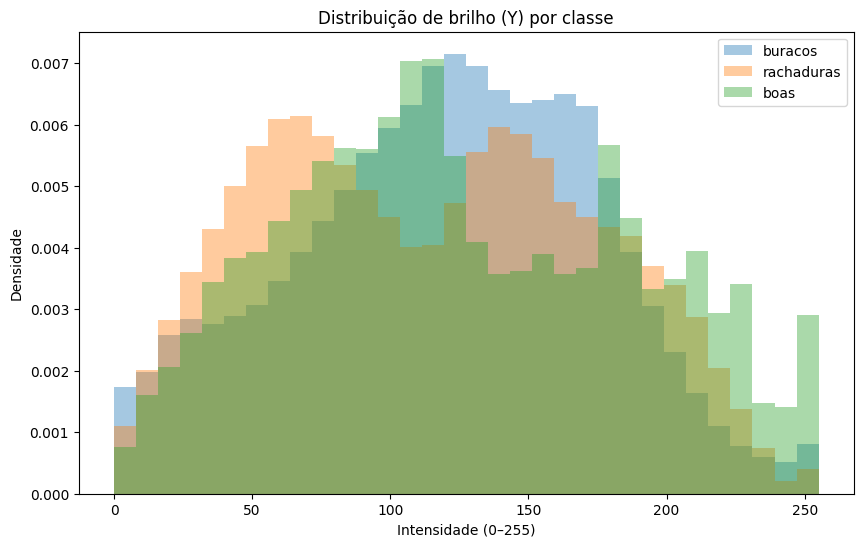

In [26]:
def luminance_rgb(img_rgb):
    # Y aproximado (ITU-R BT.601)
    r,g,b = img_rgb[...,0], img_rgb[...,1], img_rgb[...,2]
    return 0.299*r + 0.587*g + 0.114*b

import matplotlib.pyplot as plt

def plot_brightness_histograms(samples_per_class=30, bins=32):
    plt.figure(figsize=(10,6))
    for cls_id, cls in enumerate(CLASSES):
        idxs = [i for i,v in enumerate(y_raw) if v==cls_id]
        random.shuffle(idxs)
        vals=[]
        for k in idxs[:samples_per_class]:
            Y = luminance_rgb(raw[k]).ravel()
            vals.append(Y)
        vals = np.concatenate(vals)
        plt.hist(vals, bins=bins, alpha=0.4, label=cls, density=True)
    plt.title("Distribuição de brilho (Y) por classe")
    plt.xlabel("Intensidade (0–255)"); plt.ylabel("Densidade")
    plt.legend(); plt.show()

plot_brightness_histograms()


In [27]:
import os, cv2, numpy as np
sizes = []
for cls in CLASSES:
    p = DATA_DIR/cls
    for f in os.listdir(p):
        if f.lower().endswith((".jpg",".jpeg",".png")):
            img = cv2.imread(str(p/f))
            if img is None: continue
            h,w = img.shape[:2]
            sizes.append((w,h))
arr = np.array(sizes)
print("Exemplos de tamanhos originais (w,h):", arr[:10], "…")


Exemplos de tamanhos originais (w,h): [[ 640  640]
 [ 450  600]
 [ 590  350]
 [1600  904]
 [ 780  439]
 [1632 1224]
 [2400 1600]
 [ 330  244]
 [1599 1057]
 [1368  768]] …


In [28]:
def stratified_split(y, train=0.7, val=0.15):
    y = np.asarray(y); idx_tr, idx_va, idx_te = [], [], []
    for c in np.unique(y):
        idx = np.where(y==c)[0]; np.random.shuffle(idx)
        n=len(idx); ntr=int(round(train*n)); nva=int(round(val*n))
        idx_tr += idx[:ntr].tolist()
        idx_va += idx[ntr:ntr+nva].tolist()
        idx_te += idx[ntr+nva:].tolist()
    return np.array(idx_tr), np.array(idx_va), np.array(idx_te)

# Vamos salvar e reutilizar os mesmos índices nas 3 variações:
SPLIT_PATH = SAVE_DIR/"splits.json"


In [29]:
def load_images_raw(folder_path='dataset', size=(224,224)):
    X, y = [], []
    for label, cls in enumerate(CLASSES):
        p = Path(folder_path)/cls
        for f in os.listdir(p):
            if f.lower().endswith((".jpg",".jpeg",".png")):
                img = cv2.imread(str(p/f))        # BGR
                if img is None: continue
                img = cv2.resize(img, size)
                X.append(img); y.append(label)
    X = np.array(X, dtype=np.uint8)
    y = np.array(y, dtype=np.int64)
    return X, y

def build_variant(variant:str):
    """
    Retorna (X_float32_flat, y_int64) para a variante escolhida.
    - raw: imagem crua [0,1], flatten
    - denoised: usa denoised do functions.load_and_resize_images, flatten
    - imgmask: concat denoised(3 canais) + mask(1 canal), flatten
    """
    if variant == "raw":
        Xraw, y = load_images_raw(folder_path=str(DATA_DIR), size=(224,224))
        X = (Xraw.astype(np.float32)/255.0).transpose(0,3,1,2) # N,C,H,W
        X = X.reshape(X.shape[0], -1)
        return X, y

    # usa o loader do Ivo (aplica preprocess: medianBlur + Sobel + resize 224)
    denoised, mask, y = load_and_resize_images(folder_path=str(DATA_DIR), size=(512,512))

    Xden = (denoised.astype(np.float32)/255.0).transpose(0,3,1,2)  # N,3,224,224
    if variant == "denoised":
        X = Xden.reshape(Xden.shape[0], -1)
        return X, y

    if variant == "imgmask":
        M = (mask.astype(np.float32)/255.0)[:,None,:,:]             # N,1,224,224
        X4 = np.concatenate([Xden, M], axis=1)                      # N,4,224,224
        X = X4.reshape(X4.shape[0], -1)
        return X, y

    raise ValueError("variant deve ser 'raw', 'denoised' ou 'imgmask'")


In [30]:
class Perceptron(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_classes)
    def forward(self, x): return self.fc(x)

class MLPShallow(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=256, p=0.2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(p), nn.Linear(hidden, n_classes))
    def forward(self,x): return self.net(x)

@torch.no_grad()
def eval_epoch(model, loader, device, n_classes):
    model.eval(); correct=0; total=0
    conf = torch.zeros((n_classes,n_classes), dtype=torch.int64)
    for xb,yb in loader:
        xb,yb = xb.to(device), yb.to(device)
        pred = model(xb).argmax(1)
        correct += (pred==yb).sum().item(); total += yb.size(0)
        for t,p in zip(yb.view(-1), pred.view(-1)): conf[t.long(), p.long()] += 1
    return correct/max(1,total), conf.cpu().numpy()

def run_training(X, y, idx_tr, idx_va, idx_te, *, epochs=20, batch=32, lr=1e-3, hidden=256, perceptron=False):
    n_classes=len(CLASSES); in_dim = X.shape[1]
    def take(ix): return torch.from_numpy(X[ix]).float(), torch.from_numpy(y[ix]).long()
    Xtr,ytr=take(idx_tr); Xva,yva=take(idx_va); Xte,yte=take(idx_te)
    tr_dl=DataLoader(TensorDataset(Xtr,ytr), batch_size=batch, shuffle=True)
    va_dl=DataLoader(TensorDataset(Xva,yva), batch_size=batch, shuffle=False)
    te_dl=DataLoader(TensorDataset(Xte,yte), batch_size=batch, shuffle=False)

    model = (Perceptron(in_dim, n_classes) if perceptron else MLPShallow(in_dim, n_classes, hidden)).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    best_va=-1; best_state=None; patience=5; bad=0
    for ep in range(1, epochs+1):
        model.train(); acc_va=0
        loss_sum=0; n=0
        for xb,yb in tr_dl:
            xb,yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); out = model(xb); loss = loss_fn(out,yb)
            loss.backward(); opt.step()
            loss_sum += loss.item()*yb.size(0); n+=yb.size(0)
        acc_va,_ = eval_epoch(model, va_dl, DEVICE, n_classes)
        print(f"epoch {ep:02d} loss {loss_sum/max(1,n):.4f} val_acc {acc_va:.4f}")
        if acc_va>best_va: best_va=acc_va; best_state={k:v.cpu() for k,v in model.state_dict().items()}; bad=0
        else:
            bad+=1
            if bad>=patience: print("early stopping"); break

    if best_state is not None: model.load_state_dict(best_state)
    test_acc, conf = eval_epoch(model, te_dl, DEVICE, n_classes)
    return {"val_best_acc": float(best_va), "test_acc": float(test_acc)}, conf


In [31]:
set_seed()
X_raw, y_raw = build_variant("raw")

# Split compartilhado para as 3 variações (salvaremos)
idx_tr, idx_va, idx_te = stratified_split(y_raw, 0.7, 0.15)
with open(SPLIT_PATH, "w", encoding="utf-8") as f:
    json.dump({"train": idx_tr.tolist(), "val": idx_va.tolist(), "test": idx_te.tolist()}, f)

metrics_raw, conf_raw = run_training(X_raw, y_raw, idx_tr, idx_va, idx_te, epochs=20, batch=32, lr=1e-3, hidden=256)
np.save(SAVE_DIR/"confusion_raw.npy", conf_raw)
with open(SAVE_DIR/"metrics_raw.json","w") as f: json.dump(metrics_raw, f, indent=2)
metrics_raw


epoch 01 loss 48.8974 val_acc 0.5844
epoch 02 loss 17.5123 val_acc 0.3896
epoch 03 loss 7.3504 val_acc 0.2857
epoch 04 loss 2.3283 val_acc 0.3377
epoch 05 loss 0.9912 val_acc 0.3766
epoch 06 loss 0.9259 val_acc 0.6104
epoch 07 loss 0.8615 val_acc 0.5974
epoch 08 loss 0.8417 val_acc 0.5455
epoch 09 loss 0.8115 val_acc 0.5714
epoch 10 loss 0.8158 val_acc 0.6234
epoch 11 loss 0.7772 val_acc 0.5325
epoch 12 loss 0.7959 val_acc 0.4545
epoch 13 loss 0.8234 val_acc 0.6104
epoch 14 loss 0.7694 val_acc 0.6494
epoch 15 loss 0.7896 val_acc 0.5974
epoch 16 loss 0.8326 val_acc 0.6104
epoch 17 loss 0.7658 val_acc 0.6104
epoch 18 loss 0.7757 val_acc 0.6104
epoch 19 loss 0.7412 val_acc 0.5714
early stopping


{'val_best_acc': 0.6493506493506493, 'test_acc': 0.6363636363636364}

In [32]:
set_seed()
X_den, y_den = build_variant("denoised")

# Reutiliza os MESMOS índices
with open(SPLIT_PATH,"r",encoding="utf-8") as f: sp=json.load(f)
idx_tr=np.array(sp["train"]); idx_va=np.array(sp["val"]); idx_te=np.array(sp["test"])

metrics_den, conf_den = run_training(X_den, y_den, idx_tr, idx_va, idx_te, epochs=20, batch=32, lr=1e-3, hidden=256)
np.save(SAVE_DIR/"confusion_denoised.npy", conf_den)
with open(SAVE_DIR/"metrics_denoised.json","w") as f: json.dump(metrics_den, f, indent=2)
metrics_den


Total de imagens: 511
Total de labels: 511
epoch 01 loss 44.6600 val_acc 0.6234
epoch 02 loss 19.6752 val_acc 0.5844
epoch 03 loss 6.4484 val_acc 0.6234
epoch 04 loss 2.6357 val_acc 0.4026
epoch 05 loss 1.0988 val_acc 0.4156
epoch 06 loss 0.9336 val_acc 0.5974
early stopping


{'val_best_acc': 0.6233766233766234, 'test_acc': 0.5844155844155844}

In [33]:
set_seed()
X_im, y_im = build_variant("imgmask")
with open(SPLIT_PATH,"r",encoding="utf-8") as f: sp=json.load(f)
idx_tr=np.array(sp["train"]); idx_va=np.array(sp["val"]); idx_te=np.array(sp["test"])

metrics_im, conf_im = run_training(X_im, y_im, idx_tr, idx_va, idx_te, epochs=20, batch=32, lr=1e-3, hidden=256)
np.save(SAVE_DIR/"confusion_imgmask.npy", conf_im)
with open(SAVE_DIR/"metrics_imgmask.json","w") as f: json.dump(metrics_im, f, indent=2)
metrics_im


Total de imagens: 511
Total de labels: 511
epoch 01 loss 27.6634 val_acc 0.5325
epoch 02 loss 20.1362 val_acc 0.3247
epoch 03 loss 7.5851 val_acc 0.6364
epoch 04 loss 2.9590 val_acc 0.6494
epoch 05 loss 1.8937 val_acc 0.4675
epoch 06 loss 1.6719 val_acc 0.6883
epoch 07 loss 0.8806 val_acc 0.6753
epoch 08 loss 0.7369 val_acc 0.6104
epoch 09 loss 0.6814 val_acc 0.6104
epoch 10 loss 0.7210 val_acc 0.6234
epoch 11 loss 0.7756 val_acc 0.6494
early stopping


{'val_best_acc': 0.6883116883116883, 'test_acc': 0.7142857142857143}

In [34]:
import pandas as pd, numpy as np, json
def load_json(p): 
    with open(p,"r") as f: return json.load(f)
df = pd.DataFrame([
    {"Variante":"raw",      **load_json(SAVE_DIR/"metrics_raw.json")},
    {"Variante":"denoised", **load_json(SAVE_DIR/"metrics_denoised.json")},
    {"Variante":"img+mask", **load_json(SAVE_DIR/"metrics_imgmask.json")},
])
df


,Variante,val_best_acc,test_acc
0,raw,0.649351,0.636364
1,denoised,0.623377,0.584416
2,img+mask,0.688312,0.714286
